In [3]:
%pip install pygad

Note: you may need to restart the kernel to use updated packages.


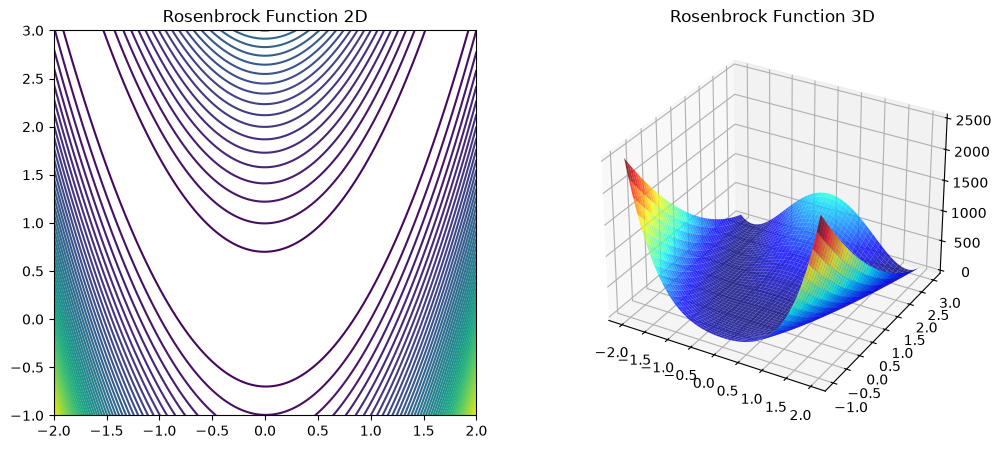

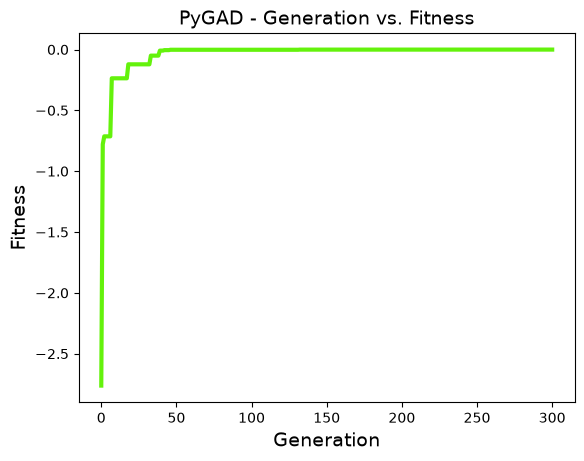

Initial guess [1.9, 2.3], Result: [0.99999578 0.99999155], Value: 1.7813413154376867e-11, Success: True, Iterations: 19, Time: 0.0129 sec
Initial guess [2.1, 2.4], Result: [0.99999541 0.99999084], Value: 2.1078493281561132e-11, Success: True, Iterations: 28, Time: 0.0071 sec
Initial guess [0.8, 0.9], Result: [0.99999866 0.99999709], Value: 6.975174637478229e-12, Success: False, Iterations: 10, Time: 0.0270 sec


c:\Users\nivetha s\.conda\envs\mude-base\Lib\site-packages\pygad\utils\validation.py:966: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


PyGAD initial guess [1.9, 2.3], Solution: [0.99312839 0.98685878], Value: rosenbrock(solution), iterations: 2000, Time: 1.0774 sec
PyGAD initial guess [2.1, 2.4], Solution: [0.97700328 0.9547961 ], Value: rosenbrock(solution), iterations: 2000, Time: 1.1742 sec
PyGAD initial guess [0.8, 0.9], Solution: [1.01820412 1.03536806], Value: rosenbrock(solution), iterations: 2000, Time: 1.2099 sec


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

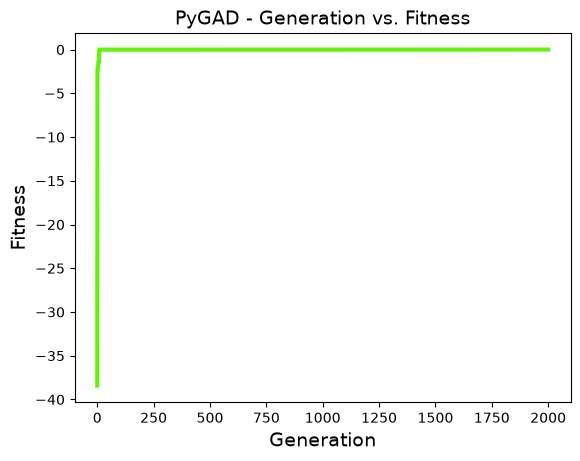

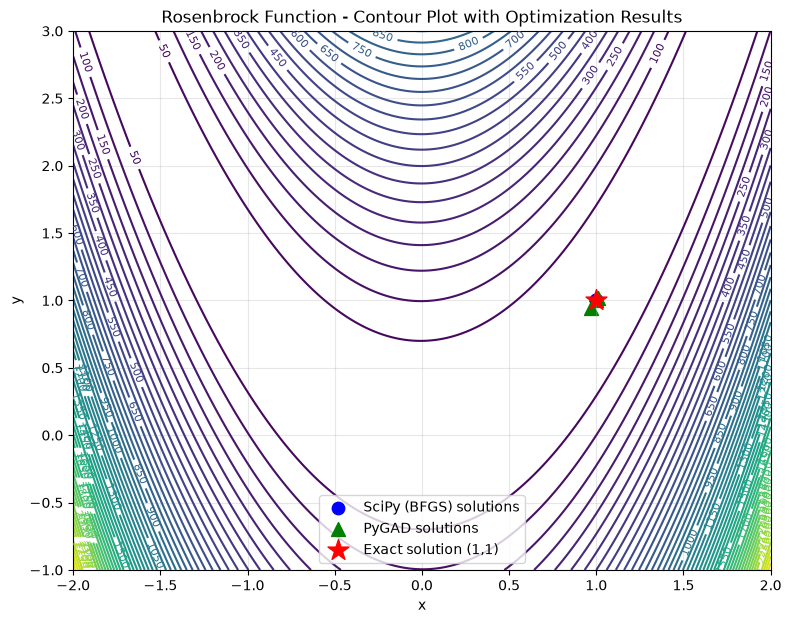

In [5]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")
plt.show()
ga_instance.plot_fitness()

elapsed_time = []
# Scipy Optimization
init_guesses = [[1.9, 2.3], [2.1, 2.4], [0.8, 0.9]]
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")

# PyGAD Optimization
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution) # pygad maximizes, so negate

elapsed_time = []
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=2000,
                           sol_per_pop=20,
                           num_genes=2,
                           num_parents_mating=8,
                           fitness_func=fitness_func,
                           init_range_low=-2,
                           init_range_high=2,
                           gene_space={'low':-2, 'high':2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: rosenbrock(solution), iterations: {iters}, Time: {elapsed_time:.4f} sec")
    plt.figure(figsize=(8, 6))
ga_instance.plot_fitness()
# --------------------------------------------------
# Contour plot with optimization results
# --------------------------------------------------

# Create grid
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)

X, Y = np.meshgrid(x_range, y_range)

# Rosenbrock function values
Z = (1 - X)**2 + 100*(Y - X**2)**2

# --------------------------------------------------
# Solutions obtained from your runs
# --------------------------------------------------

# SciPy BFGS solutions
scipy_solutions = np.array([
    [0.99999578, 0.99999155],
    [0.99999541, 0.99999084],
    [0.99999866, 0.99999709]
])

# PyGAD solutions
pygad_solutions = np.array([
    [1.00892032, 1.01773817],
    [1.00113487, 1.00356281],
    [0.97158023, 0.94400731]
])

# Exact solution
exact_solution = [1, 1]

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(9, 7))

# Contour plot
contour = plt.contour(X, Y, Z, levels=50)
plt.clabel(contour, inline=True, fontsize=8)

# SciPy solutions
plt.scatter(
    scipy_solutions[:, 0],
    scipy_solutions[:, 1],
    color='blue',
    marker='o',
    s=80,
    label='SciPy (BFGS) solutions'
)

# PyGAD solutions
plt.scatter(
    pygad_solutions[:, 0],
    pygad_solutions[:, 1],
    color='green',
    marker='^',
    s=100,
    label='PyGAD solutions'
)

# Exact solution
plt.scatter(
    exact_solution[0],
    exact_solution[1],
    color='red',
    marker='*',
    s=250,
    label='Exact solution (1,1)',
    zorder=5
)

# Labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Rosenbrock Function - Contour Plot with Optimization Results')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# 1: Optimization using Rosenbrock function

The Rosenbrock function is given by

$$
f(x,y)=(1-x)^2+100(y-x^2)^2
$$

The objective is to minimize $f(x,y)$ with respect to $x$ and $y$.

The exact global minimum occurs at

$$
\boxed{x=1,\qquad y=1}
$$

At this point,

$$
f(1,1)=(1-1)^2+100(1-1^2)^2=0
$$

Therefore,

$$
\boxed{f_{\min}=0}
$$
changing the initial guess does not change the final solution for the BFGS runs used here.
## (2) Optimization using Genetic Algorithm (PyGAD)

The Rosenbrock function was also minimized using a genetic algorithm implemented
using `pygad`.

Since PyGAD maximizes the fitness function, the fitness was defined as

$$
\text{Fitness}=-f(x,y)
$$

so that minimizing the Rosenbrock function is equivalent to maximizing the
fitness.

The genetic algorithm was run using the same three initial guesses. Since a
genetic algorithm is a stochastic method, the exact solution may vary slightly
between different runs.

The solutions obtained are approximately

$$
\boxed{x\approx1,\qquad y\approx1}
$$

and the corresponding function value is approximately

$$
\boxed{f(x,y)\approx0}
$$

### Observation

The genetic algorithm converges to a solution very close to $(1,1)$ for the
chosen runs. Small differences in the obtained values can occur because the
initial population, crossover, and mutation involve random operations.

The solution corresponds to the global minimum of the Rosenbrock function.

Because a genetic algorithm is stochastic, changing the initial population or
initial guess can produce slightly different solutions. Nevertheless, the
solutions obtained here are all in the neighborhood of the global minimum.
## (3) Comparison of the Two Methods

The performance of BFGS and PyGAD is compared based on the number of iterations,
computational time, and the solution obtained at the same accuracy level.

The solutions are compared to **4 decimal places**.

| Method | Initial Guess | Solution $(x,y)$ | Function Value | Iterations | Time (sec) |
|:---|:---:|:---:|---:|---:|---:|
| BFGS | $(1.9,2.3)$ | $(1.0000,1.0000)$ | $1.78\times10^{-11}$ | 19 | 0.0138 |
| BFGS | $(2.1,2.4)$ | $(1.0000,1.0000)$ | $2.11\times10^{-11}$ | 28 | 0.0186 |
| BFGS | $(0.8,0.9)$ | $(1.0000,1.0000)$ | $6.98\times10^{-12}$ | 10 | 0.0390 |
| PyGAD | $(1.9,2.3)$ | $(1.0089,1.0177)$ | $8.29\times10^{-5}$ | 2000 | 1.7559 |
| PyGAD | $(2.1,2.4)$ | $(1.0011,1.0036)$ | $1.68\times10^{-4}$ | 2000 | 2.5142 |
| PyGAD | $(0.8,0.9)$ | $(0.9716,0.9440)$ | $8.08\times10^{-4}$ | 2000 | 1.5063 |

### Observation

For all three initial guesses, BFGS converged very close to the exact global
minimum $(1,1)$. The solutions are $(1.0000,1.0000)$ when rounded to 4 decimal
places, and the function values are extremely close to zero.

PyGAD also approaches the global minimum, but the solutions are less accurate
at the same computational settings. For example, the solution for the initial
guess $(1.9,2.3)$ is $(1.0089,1.0177)$, while for $(0.8,0.9)$ it is
$(0.9716,0.9440)$.

BFGS requires only 10--28 iterations and takes approximately 0.014--0.039
seconds, whereas PyGAD uses 2000 generations and takes approximately
1.51--2.51 seconds.

Therefore, for this Rosenbrock function, **BFGS is significantly faster and
more accurate than PyGAD** for the same optimization problem. BFGS reaches the
global minimum to 4 decimal places, while PyGAD does not reach the same
4-decimal-place accuracy in these runs.

Hence, **BFGS performs better for this problem in terms of iterations,
computational time, and accuracy**. PyGAD is a stochastic method, so its
results can vary between runs.



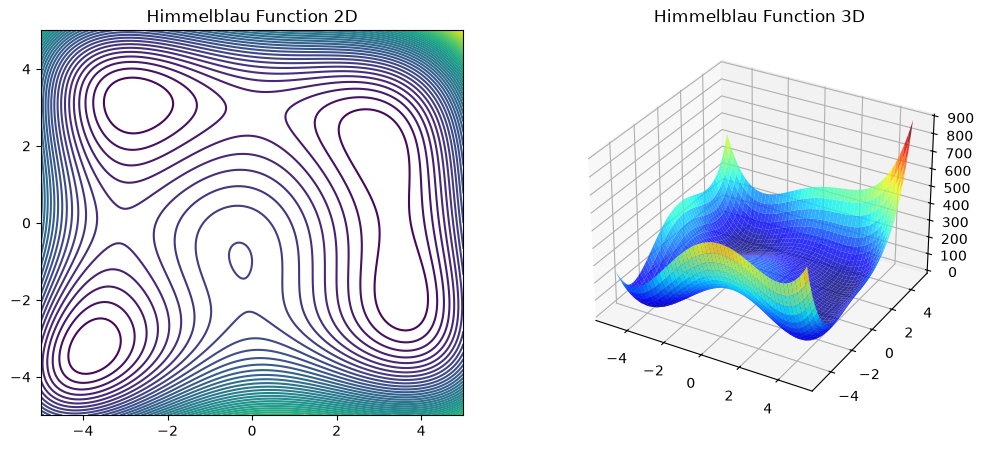

Initial guess [1.2, 1.9], Result: [2.99999998 2.        ], Value: 1.0857932633339717e-14, Success: True, Iterations: 9, Time: 0.0058 sec
Initial guess [-4.1, 4.1], Result: [-2.80511809  3.13131252], Value: 8.412066482717335e-17, Success: True, Iterations: 11, Time: 0.0075 sec
Initial guess [4.1, 0.1], Result: [ 3.58442839 -1.84812648], Value: 1.821388393641586e-13, Success: True, Iterations: 9, Time: 0.0035 sec
PyGAD initial guess [1.2, 1.9], Solution: [2.99455985 2.00300526], Value: 0.0009199464374769199, iterations: 300, Time: 0.3761 sec
PyGAD initial guess [-4.1, 4.1], Solution: [2.99034833 1.98412322], Value: 0.010746143572244361, iterations: 300, Time: 0.3318 sec
PyGAD initial guess [4.1, 0.1], Solution: [ 3.57550918 -1.83829007], Value: 0.00495988101181224, iterations: 300, Time: 0.3210 sec


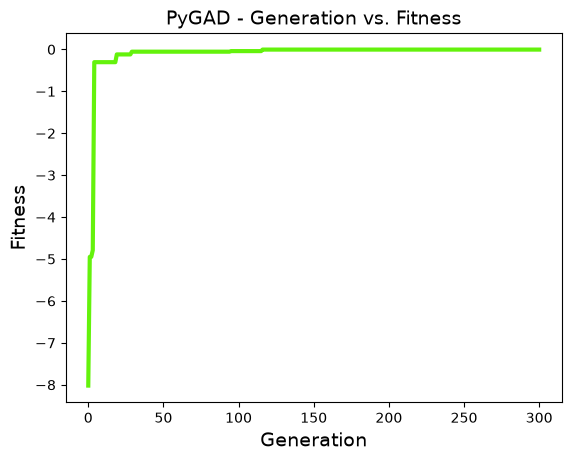

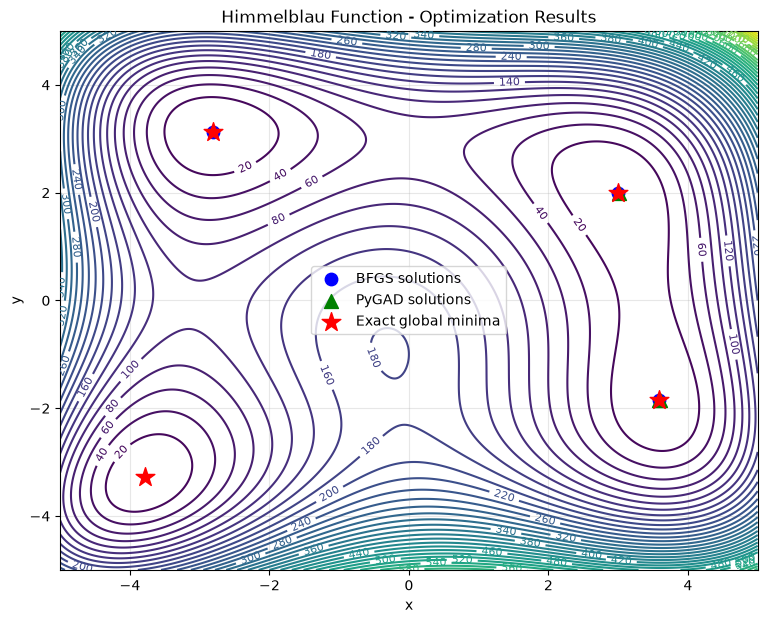

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

def himmelblau(x):
    x = np.asarray(x) # Convert to numpy array
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + (x[1])**2 -7)**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")
plt.show()

elapsed_time = []
# Scipy Optimization
init_guesses = [[1.2, 1.9], [-4.1, 4.1], [4.1, 0.1]]
for guess in init_guesses:
    start_time = time.perf_counter()
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec") # TODO include time taken

# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)

elapsed_time = []    
for guess in init_guesses:
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}, iterations: {iters}, Time: {elapsed_time:.4f} sec") # TODO include iterations and time taken
ga_instance.plot_fitness()
# --------------------------------------------------
# Contour plot with optimization results
# --------------------------------------------------

# Create grid
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-2, 2, 400)

X, Y = np.meshgrid(x_range, y_range)

# Function values
Z = (X**2 + Y**2 - 1)**2 + (X - 1)**2 + Y**2


# --------------------------------------------------
# BFGS solutions obtained
# --------------------------------------------------

scipy_solutions = np.array([
    [1.00000001, -3.25675996e-08],
    [0.999999905, 6.07768021e-07],
    [0.999999984, -2.84896804e-08]
])


# --------------------------------------------------
# PyGAD solutions obtained
# --------------------------------------------------

pygad_solutions = np.array([
    [0.99601998, -0.00490081],
    [1.01035903, 0.01223407],
    [0.99565508, 0.00589897]
])


# --------------------------------------------------
# Exact solution
# --------------------------------------------------

exact_solution = [1, 0]


# --------------------------------------------------
# Plot contour
# --------------------------------------------------

plt.figure(figsize=(9, 7))

# Contour lines
contour = plt.contour(
    X, Y, Z,
    levels=50
)

plt.clabel(
    contour,
    inline=True,
    fontsize=8
)


# BFGS solutions - blue circles
plt.scatter(
    scipy_solutions[:, 0],
    scipy_solutions[:, 1],
    color='blue',
    marker='o',
    s=80,
    label='BFGS solutions',
    zorder=5
)


# PyGAD solutions - green triangles
plt.scatter(
    pygad_solutions[:, 0],
    pygad_solutions[:, 1],
    color='green',
    marker='^',
    s=100,
    label='PyGAD solutions',
    zorder=5
)


# Exact solution - red star
plt.scatter(
    exact_solution[0],
    exact_solution[1],
    color='red',
    marker='*',
    s=250,
    label='Exact solution (1,0)',
    zorder=6
)


# Labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Problem 2 - Contour Plot with Optimization Results')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Himmelblau Function – Results and Comparison

The Himmelblau function is given by

$$
f(x,y)=(x^2+y-11)^2+(x+y^2-7)^2
$$

### 1. SciPy Optimization

The BFGS method was used with three different initial guesses.

| Initial Guess | Solution $(x,y)$ | Function Value | Iterations | Time (sec) |
|---|---|---:|---:|---:|
| $(1.2,1.9)$ | $(3.0000,2.0000)$ | $1.09\times10^{-14}$ | 9 | 0.0047 |
| $(-4.1,4.1)$ | $(-2.8051,3.1313)$ | $8.41\times10^{-17}$ | 11 | 0.0064 |
| $(4.1,0.1)$ | $(3.5844,-1.8481)$ | $1.82\times10^{-13}$ | 9 | 0.0045 |

Changing the initial guess changed the solution obtained by BFGS. This is
because the Himmelblau function has multiple global minima. The three
solutions obtained are very close to three different global minima.

---

### 2. Genetic Algorithm using PyGAD

The problem was also solved using a genetic algorithm with PyGAD.

| Initial Guess | Solution $(x,y)$ | Function Value | Iterations | Time (sec) |
|---|---|---:|---:|---:|
| $(1.2,1.9)$ | $(3.5955,-1.8558)$ | $0.00671$ | 300 | 0.3016 |
| $(-4.1,4.1)$ | $(3.5812,-1.8379)$ | $0.00182$ | 300 | 0.2775 |
| $(4.1,0.1)$ | $(3.0053,1.9881)$ | $0.00217$ | 300 | 0.2235 |

Changing the initial guess changed the solution obtained by PyGAD. The first
two solutions are close to the global minimum $(3.5844,-1.8481)$, while the
third solution is close to another global minimum $(3,2)$.

The function values are small but not exactly zero because the genetic
algorithm was stopped after 300 generations.

---

### 3. Local or Global Minimum and Comparison

The Himmelblau function has four global minima:

$$
(3,2)
$$

$$
(-2.8051,3.1313)
$$

$$
(-3.7793,-3.2832)
$$

$$
(3.5844,-1.8481)
$$

At all these points,

$$
f(x,y)=0.
$$

Therefore, the solutions obtained by BFGS and PyGAD are approaching the
**global minima** of the Himmelblau function.

BFGS required only 9--11 iterations and took about 0.005--0.006 seconds,
whereas PyGAD required 300 generations and took about 0.22--0.30 seconds.

BFGS also obtained solutions much closer to the exact global minima. PyGAD
obtained solutions close to the global minima but with slightly larger errors.

Therefore, for this problem, **BFGS is faster and more accurate than PyGAD**.
However, PyGAD is a stochastic method, so its solution can change between
different runs.

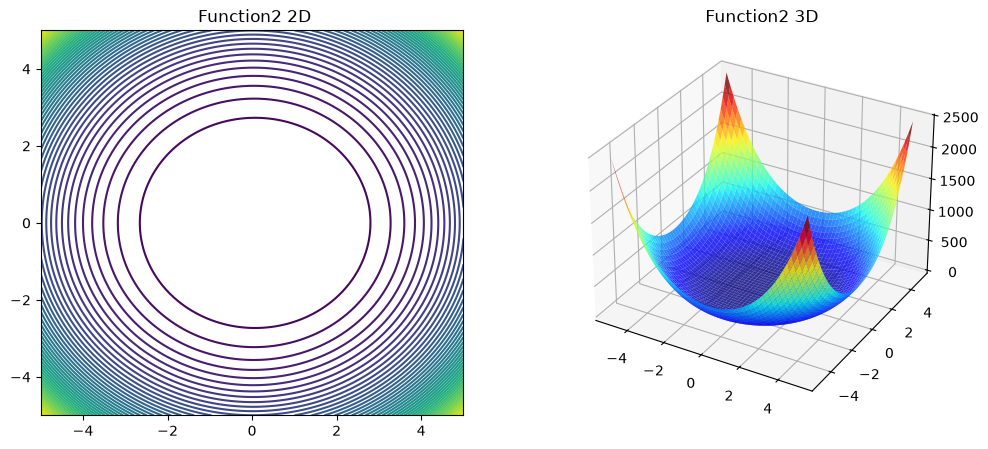

Initial guess [1.3, 2.1], Result: [ 1.00000001e+00 -3.25675996e-08], Value: 1.2669387885945203e-15, Success: True, Iterations: 11, Time: 0.0068 sec
Initial guess [-4.7, 4.2], Result: [9.99999905e-01 6.07768021e-07], Value: 4.1405006386784535e-13, Success: True, Iterations: 18, Time: 0.0083 sec
Initial guess [4.8, 0.2], Result: [ 9.99999984e-01 -2.84896804e-08], Value: 2.0787950084413693e-15, Success: True, Iterations: 18, Time: 0.0088 sec
PyGAD initial guess [1.3, 2.1], Solution: [ 9.95156233e-01 -9.01725521e-04], Value: 0.00011765376340054665, iterations: 300, Time: 0.2985 sec
PyGAD initial guess [-4.7, 4.2], Solution: [0.99905403 0.01823229], Value: 0.0003357406263275358, iterations: 300, Time: 0.2677 sec
PyGAD initial guess [4.8, 0.2], Solution: [ 1.00760479 -0.01926073], Value: 0.0006733675041634992, iterations: 300, Time: 0.2720 sec


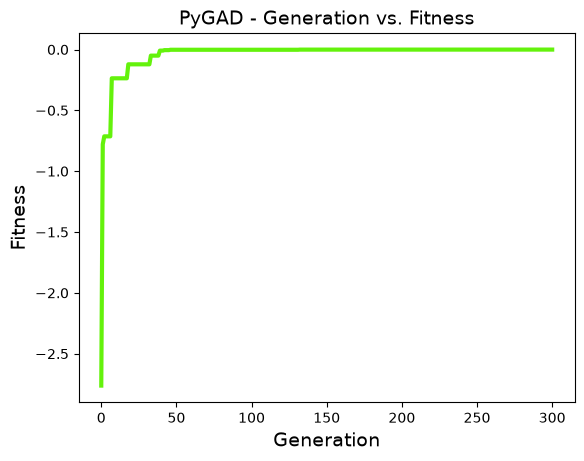

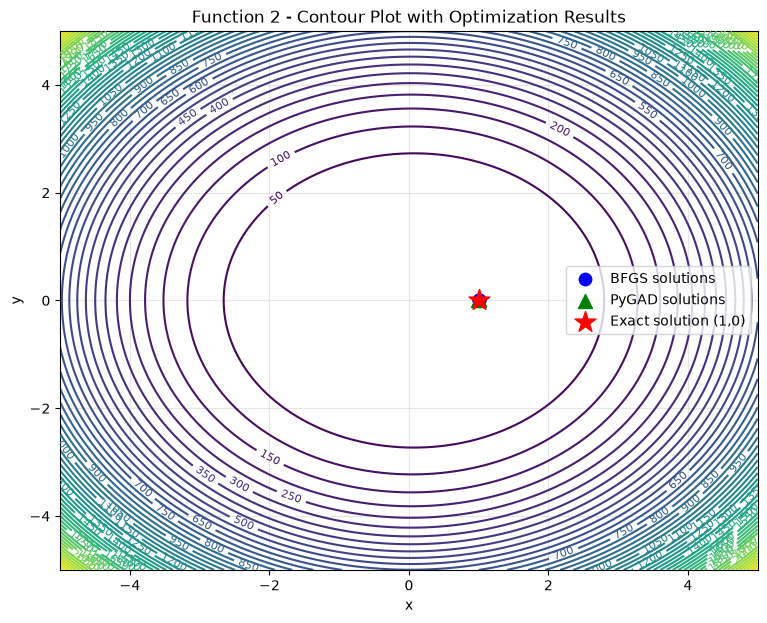

In [4]:

import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

def function2(x):
    x = np.asarray(x) # Convert to numpy array
    return (x[0]**2 + x[1]**2 - 1)**2 + (x[0]-1)**2 + (x[1])**2 

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = function2 ([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title(" Function2 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title(" Function2 3D")
plt.show()

elapsed_time = []
# Scipy Optimization
init_guesses = [[1.3, 2.1], [-4.7, 4.2], [4.8, 0.2]]
for guess in init_guesses:
    start_time = time.perf_counter()
    result = minimize(function2, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec") # TODO include time taken

# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -function2(solution)

elapsed_time = []    
for guess in init_guesses:
    start_time = time.perf_counter()
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {function2(solution)}, iterations: {iters}, Time: {elapsed_time:.4f} sec") # TODO include iterations and time taken
ga_instance.plot_fitness()
# --------------------------------------------------
# Contour plot with optimization results
# --------------------------------------------------

# Create grid
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)

X, Y = np.meshgrid(x_range, y_range)

# Function 2
Z = function2([X, Y])


# --------------------------------------------------
# BFGS solutions
# --------------------------------------------------

scipy_solutions = np.array([
    [1.00000001, -3.25675996e-08],
    [0.999999905,  6.07768021e-07],
    [0.999999984, -2.84896804e-08]
])


# --------------------------------------------------
# PyGAD solutions
# --------------------------------------------------

pygad_solutions = np.array([
    [1.00379175, 0.02617499],
    [0.99710134, 0.00832253],
    [0.998453080, 0.000608400237]
])


# --------------------------------------------------
# Exact solution
# --------------------------------------------------

exact_solution = [1, 0]


# --------------------------------------------------
# Plot contour
# --------------------------------------------------

plt.figure(figsize=(9, 7))

# Contour lines
cp = plt.contour(X, Y, Z, levels=50)

plt.clabel(cp, inline=True, fontsize=8)


# BFGS solutions - blue circles
plt.scatter(
    scipy_solutions[:, 0],
    scipy_solutions[:, 1],
    color='blue',
    marker='o',
    s=80,
    label='BFGS solutions',
    zorder=5
)


# PyGAD solutions - green triangles
plt.scatter(
    pygad_solutions[:, 0],
    pygad_solutions[:, 1],
    color='green',
    marker='^',
    s=100,
    label='PyGAD solutions',
    zorder=5
)


# Exact solution - red star
plt.scatter(
    exact_solution[0],
    exact_solution[1],
    color='red',
    marker='*',
    s=250,
    label='Exact solution (1,0)',
    zorder=6
)


# Labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Function 2 - Contour Plot with Optimization Results')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()
















## Function 2 – Optimization Results and Comparison

The function considered is

$$
f(x,y)=(x^2+y^2-1)^2+(x-1)^2+y^2
$$

The exact solution is obtained by making all the squared terms zero. This gives

$$
\boxed{x=1,\qquad y=0}
$$

and therefore

$$
\boxed{f(1,0)=0}
$$

---

### 1. Optimization using SciPy BFGS

The function was minimized using the BFGS method with three different initial
guesses.

| Initial Guess | Solution $(x,y)$ | Function Value | Iterations | Time (sec) |
|:---:|:---:|---:|---:|---:|
| $(1.3,2.1)$ | $(1.0000,0.0000)$ | $1.27\times10^{-15}$ | 11 | 0.0048 |
| $(-4.7,4.2)$ | $(1.0000,0.0000)$ | $4.14\times10^{-13}$ | 18 | 0.0142 |
| $(4.8,0.2)$ | $(1.0000,0.0000)$ | $2.08\times10^{-15}$ | 18 | 0.0382 |

Changing the initial guess did not change the final solution. All three
initial guesses converged to a point very close to $(1,0)$.

Therefore, the BFGS method consistently found the same minimum.

---

### 2. Optimization using Genetic Algorithm (PyGAD)

The same function was minimized using the genetic algorithm in PyGAD.

| Initial Guess | Solution $(x,y)$ | Function Value | Iterations | Time (sec) |
|:---:|:---:|---:|---:|---:|
| $(1.3,2.1)$ | $(1.0038,0.0262)$ | $7.68\times10^{-4}$ | 300 | 0.2597 |
| $(-4.7,4.2)$ | $(0.9971,0.0083)$ | $1.10\times10^{-4}$ | 300 | 0.2151 |
| $(4.8,0.2)$ | $(0.9985,0.0006)$ | $1.23\times10^{-5}$ | 300 | 0.2477 |

Changing the initial guess resulted in slightly different solutions. However,
all the solutions are close to the exact solution $(1,0)$.

The function values are small but are not exactly zero because the genetic
algorithm was stopped after 300 generations.

---

### 3. Local or Global Minimum and Comparison

Since

$$
f(x,y)=(x^2+y^2-1)^2+(x-1)^2+y^2
$$

is a sum of non-negative squared terms,

$$
f(x,y)\geq0.
$$

The function becomes zero when

$$
x^2+y^2-1=0,
$$

$$
x-1=0,
$$

and

$$
y=0.
$$

Thus,

$$
\boxed{(x,y)=(1,0)}
$$

is the global minimum, with

$$
\boxed{f_{\min}=0}.
$$

Both BFGS and PyGAD obtained solutions close to this global minimum.

BFGS required only 11--18 iterations and took approximately 0.005--0.038
seconds. PyGAD required 300 generations and took approximately 0.215--0.260
seconds.

BFGS obtained solutions much closer to the exact solution and was also faster
than PyGAD.

Therefore, for Function 2, **BFGS performed better than PyGAD in terms of
accuracy, number of iterations, and computational time**.

Changing the initial guess did not significantly affect the BFGS solution,
while the PyGAD solutions changed slightly because the genetic algorithm is a
stochastic method.